In [36]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Le Modèle LSTM ###

In [37]:
# -----------------------
# Modèle LSTM
# -----------------------
class LSTMModel(nn.Module): 
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])  # on prend le dernier pas de temps
        return out

### Génération des données (série temporelle) ###

In [38]:
# -----------------------
# 1. Génération des données (série temporelle)
# Exemple : sinusoïde bruitée
# -----------------------
time_steps = 300
x = np.linspace(0, 30, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

### Création des séquences glissantes ###

In [39]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 15
X, y = create_sequences(data, seq_length)
                        
                        # Conversion en tenseurs PyTorch
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (batch, seq_len, 1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (batch, 1)

### Initialisation du modèle ###

In [40]:
model = LSTMModel(input_size=1, hidden_size=50, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### Entraînement ###

In [41]:
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 0.0136
Epoch [100/300], Loss: 0.0112
Epoch [150/300], Loss: 0.0101
Epoch [200/300], Loss: 0.0104
Epoch [250/300], Loss: 0.0094
Epoch [300/300], Loss: 0.0092


### Prédiction ###

In [42]:
model.eval()
with torch.no_grad():
    predictions = model(X)

predictions = predictions.squeeze().numpy()
y_true = y.squeeze().numpy()

### Visualisation ###

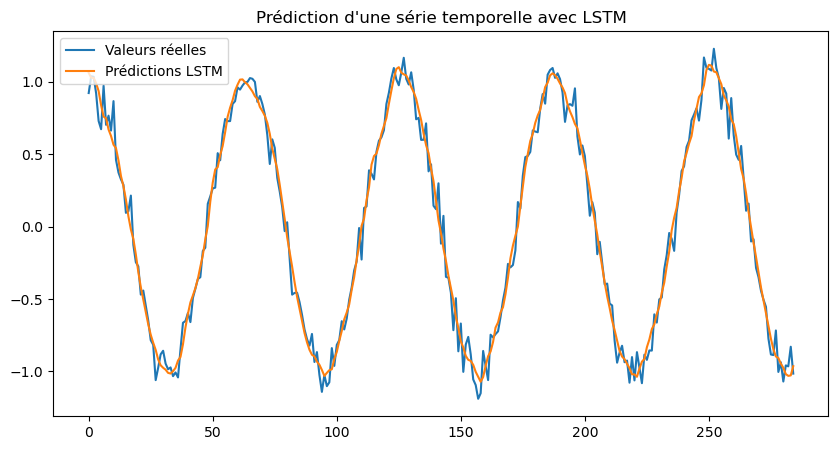

In [43]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label="Valeurs réelles")
plt.plot(predictions, label="Prédictions LSTM")
plt.legend()
plt.title("Prédiction d'une série temporelle avec LSTM")
plt.show()